# Object Tracking — Practical Notebook
## STUDENT VERSION — fill in every `TODO`

**Companion lab for the lecture: SORT, DeepSORT, ByteTrack, and tracking metrics.**

---

Real-world tracking is **library work, not from-scratch work** — nobody hand-writes a Kalman filter for production. This lab uses the same stack engineers reach for in real projects:

- **`ultralytics`** — YOLO for object detection.
- **`trackers`** — Roboflow's modern tracker package (SORT, ByteTrack).
- **`deep-sort-realtime`** — the canonical maintained DeepSORT.
- **`supervision`** — video I/O, annotation, sample videos.
- **`motmetrics`** — MOTA / MOTP / IDF1 / ID switches.

### How to use this notebook
Cells marked **`# TODO`** are yours to complete. The TODOs are about **running, tuning, and comparing** trackers — not implementing Kalman filters. Cells without a TODO (setup, video download, plotting helpers, the YOLO detector) are given to you complete — read and run them.

Work top to bottom: later cells depend on earlier ones.

> **How to run this:** Google Colab with a GPU is easiest. CPU works too, just slower.


## 1 · Setup & install

We install five packages. If you are running locally, uncomment the `pip install` line. On Colab, run it as-is the first time.


In [1]:
!pip install -q ultralytics supervision trackers deep-sort-realtime motmetrics

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch

# Compatibility shim for motmetrics 1.4.0 (unmaintained) on NumPy >= 2.0.
# motmetrics still calls the removed np.asfarray; restore it as an alias.
if not hasattr(np, "asfarray"):
    np.asfarray = lambda a, dtype=np.float64: np.asarray(a, dtype=dtype)

import supervision as sv
from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch device     :", device)
print("supervision version:", sv.__version__)


PyTorch device     : cuda
supervision version: 0.29.1


## 2 · The tracking-by-detection pipeline

> *Lecture recap:* every algorithm in the lecture (SORT, DeepSORT, ByteTrack) follows the same blueprint:
>
> ```
>   frame --> [ DETECTOR ] --> detections --> [ TRACKER ] --> tracked detections
>                 (YOLO)        (boxes,conf)    (assigns IDs)    (boxes,conf,track_id)
> ```
>
> The **detector** finds objects independently in each frame. The **tracker** strings those per-frame detections together into trajectories, assigning a *consistent ID* to each object over time. The trackers differ *only in how they do that matching* — Kalman + IoU (SORT), + appearance (DeepSORT), + low-confidence boxes (ByteTrack).

Let's grab a real pedestrian video to use throughout the lab. `supervision` ships sample videos as a convenience — one function call.


In [2]:
from supervision.assets import download_assets, VideoAssets

# Roboflow's PEOPLE_WALKING video -- a real pedestrian clip, perfect for tracking.
VIDEO_PATH = download_assets(VideoAssets.PEOPLE_WALKING)
info = sv.VideoInfo.from_video_path(VIDEO_PATH)
print("video file :", VIDEO_PATH)
print("resolution :", info.resolution_wh)
print("fps        :", info.fps)
print("frames     :", info.total_frames)
print("duration   :", f"{info.total_frames / info.fps:.1f}s")


[2026-06-26 18:25:46] [INFO] supervision.assets.downloader - people-walking.mp4 asset download complete.
video file : people-walking.mp4
resolution : (1920, 1080)
fps        : 25.0
frames     : 341
duration   : 13.6s


Look at one frame so you know what you're working with.


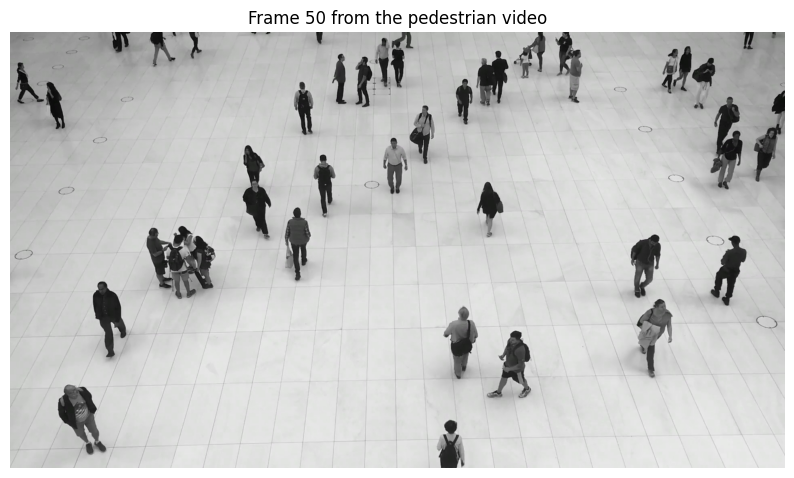

In [3]:
# Grab a single frame from the middle of the video for inspection.
frames_gen = sv.get_video_frames_generator(VIDEO_PATH)
for i, frame in enumerate(frames_gen):
    if i == 50:
        SAMPLE_FRAME = frame.copy()
        break

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(SAMPLE_FRAME, cv2.COLOR_BGR2RGB))
plt.title("Frame 50 from the pedestrian video")
plt.axis("off"); plt.show()


## 3 · Detection with YOLO

Before tracking, we need detections. We use **YOLOv8n** — the smallest, fastest YOLO — which is plenty for pedestrians. The pretrained weights are COCO-trained and recognise *person* as class index `0`.

Two practical details to internalise:
1. Load the model **once**, reuse it across all frames. Recreating a detector per frame is the single most common 'why is my pipeline slow' bug.
2. Filter to the **class of interest** at the detection stage. Trackers don't know about classes — feed them only people, or you'll spend compute tracking benches and bicycles by accident.


In [4]:
# YOLOv8n: 'n' = nano, the smallest model. Plenty for pedestrians.
yolo = YOLO("yolov8n.pt")
yolo.fuse()   # optional: fuse Conv+BN layers for a small speedup

# Run detection on the sample frame. verbose=False to keep the notebook tidy.
results = yolo(SAMPLE_FRAME, verbose=False)[0]

# supervision parses YOLO results into a clean Detections object.
detections = sv.Detections.from_ultralytics(results)

# Keep only people (COCO class 0).
PERSON_CLASS_ID = 0
detections = detections[detections.class_id == PERSON_CLASS_ID]
print(f"Detected {len(detections)} people in this frame")
print("confidences:", np.round(detections.confidence, 2))


YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
Detected 40 people in this frame
confidences: [       0.79        0.78        0.75        0.73        0.72        0.72         0.7         0.7        0.69        0.68        0.66        0.65        0.59        0.57        0.56        0.56        0.56        0.55        0.53        0.51        0.49        0.49        0.48        0.47        0.46        0.46
        0.44        0.43        0.37        0.35        0.33        0.33        0.33        0.31        0.31         0.3         0.3        0.29        0.29        0.25]


Draw the detections on the frame using `supervision`'s annotators. This is what every tracking pipeline looks like at frame 0 — no IDs yet, just boxes.


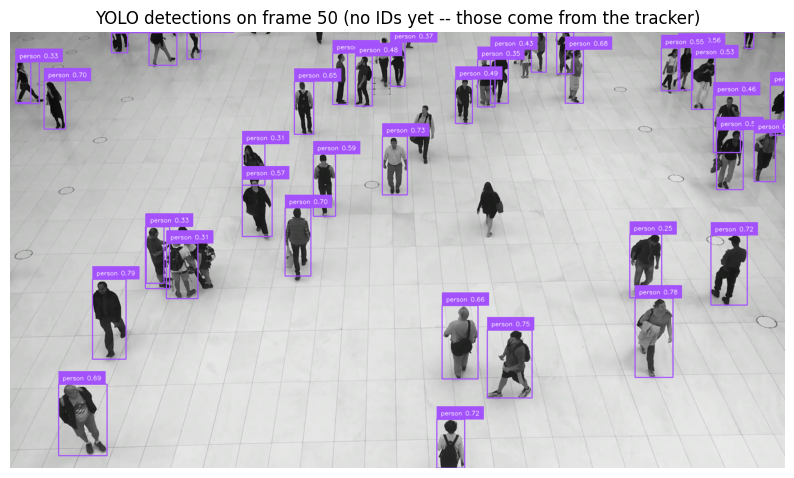

In [5]:
box_annotator   = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_thickness=1, text_scale=0.5)

annotated = box_annotator.annotate(SAMPLE_FRAME.copy(), detections=detections)
labels    = [f"person {c:.2f}" for c in detections.confidence]
annotated = label_annotator.annotate(annotated, detections=detections, labels=labels)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("YOLO detections on frame 50 (no IDs yet -- those come from the tracker)")
plt.axis("off"); plt.show()


### TODO 3.1
Run YOLO across the **first 30 frames** of the video and record how many people it detects in each. Plot a small histogram or line chart. This is the *raw signal* a tracker receives — every algorithm in this lab is fundamentally a smart way to stitch this signal together over time.


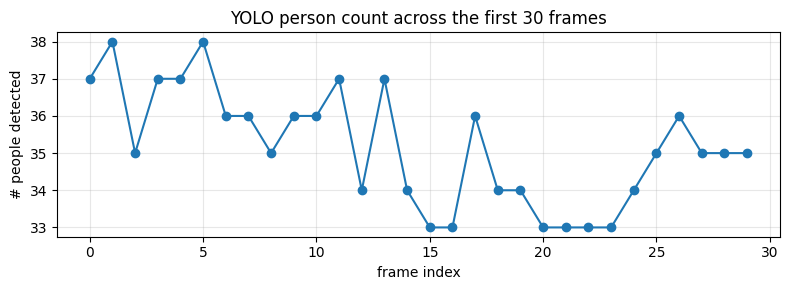

min/max/mean people per frame: 33 38 35.17


In [6]:
# TODO 3.1 -- Detection counts across the first 30 frames.
#
# Loop over the first 30 frames of VIDEO_PATH (use sv.get_video_frames_generator).
# In each frame:
#   - run YOLO with verbose=False
#   - parse with sv.Detections.from_ultralytics(...)
#   - keep only class_id == PERSON_CLASS_ID
#   - record how many detections survived
# Then plot the counts as a line chart.

counts = []
for i, frame in enumerate(sv.get_video_frames_generator(VIDEO_PATH)):
    if i >= 30:
        break
    # TODO: detect, filter to people, append the count to `counts`
    results = yolo(frame, verbose=False)[0]
    det = sv.Detections.from_ultralytics(results)
    det = det[det.class_id == PERSON_CLASS_ID]
    counts.append(len(det))

# --- given: plot ---
plt.figure(figsize=(8, 3))
plt.plot(counts, marker="o")
plt.xlabel("frame index"); plt.ylabel("# people detected")
plt.title("YOLO person count across the first 30 frames")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("min/max/mean people per frame:",
      min(counts), max(counts), round(np.mean(counts), 2))


## 4 · SORT — Simple Online Realtime Tracking

> *Lecture recap:* SORT is the baseline tracker. Per frame:
> 1. Each existing track uses its **Kalman filter** to predict where it should be in this frame.
> 2. **IoU** between predicted boxes and the new detections forms a cost matrix.
> 3. The **Hungarian algorithm** finds the optimal one-to-one matching.
> 4. Matched tracks are *updated* with the detection; unmatched detections create *tentative* tracks; unmatched tracks age out after `max_age`.
>
> SORT has **no appearance model** — purely position + motion. It is fast and works well when objects are well-separated, but ID switches rise sharply in crowds or after occlusion.

In practice you don't implement this. You import it.


In [15]:
!pip uninstall -y trackers

Found existing installation: trackers 2.5.0
Uninstalling trackers-2.5.0:
  Successfully uninstalled trackers-2.5.0


In [16]:
pip install git+https://github.com/roboflow/trackers.git

  Cloning https://github.com/roboflow/trackers.git to /tmp/pip-req-build-td63utqb
  Running command git clone --filter=blob:none --quiet https://github.com/roboflow/trackers.git /tmp/pip-req-build-td63utqb
  Resolved https://github.com/roboflow/trackers.git to commit 56bd2ccd517f1efbdb2d5a68533b9aea64d07dac
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for trackers: filename=trackers-2.5.0-py3-none-any.whl size=143956 sha256=ae6e1224f662e354560ae579d313b54bc2569e037aa0cccbf324bd86b15b6609
  Stored in directory: /tmp/pip-ephem-wheel-cache-uhy3kox4/wheels/2e/2f/91/d5b27468b0a30dfe3f034939dd04eb9b7452f097d62d651f7e
Successfully built trackers


In [17]:
from trackers import SORTTracker

# Key hyperparameters (these are the lecture's hyperparameters by another name):
#   minimum_consecutive_frames -- the 'probation age': how many consecutive
#                                 matches before a tentative track is confirmed.
#                                 (Higher = fewer false-positive tracks, slower
#                                 to start tracking new objects.)
#   lost_track_buffer          -- the 'max age': how long to keep a track in
#                                 shadow tracking after losing detections.
#                                 (Higher = better occlusion recovery, more
#                                 lingering 'ghost' tracks.)
sort_tracker = SORTTracker(
    minimum_consecutive_frames=3,
    lost_track_buffer=30,
)
print("SORTTracker ready:", sort_tracker)


SORTTracker ready: <trackers.core.sort.tracker.SORTTracker object at 0x7e5b0c0e89e0>


Now run SORT over the **whole pedestrian video**. The pattern is identical for every tracker we'll use: YOLO detects → tracker assigns IDs → annotator draws boxes with IDs → `sv.process_video` writes out a new MP4. You'll see this exact pattern three more times in this notebook.


In [18]:
# TODO 4.1 -- Wire up the YOLO -> SORT -> annotate -> save pipeline.
#
# Implement `sort_callback`. It receives a single video frame and must:
#   1. detect:   results = yolo(frame, verbose=False)[0]
#                det     = sv.Detections.from_ultralytics(results)
#                det     = det[det.class_id == PERSON_CLASS_ID]
#   2. track:    det = sort_tracker.update(det)
#                (this fills in det.tracker_id with stable IDs)
#   3. annotate: build label strings like "#{tracker_id}", then apply
#                box_ann, label_ann, trace_ann in that order. Each
#                annotator's .annotate() returns the annotated frame.
#
# Then `sv.process_video` runs the callback over every frame and writes a
# new MP4. You'll re-use this exact pattern for DeepSORT and ByteTrack.

SORT_OUT = "sort_output.mp4"
box_ann   = sv.BoxAnnotator(thickness=2)
label_ann = sv.LabelAnnotator(text_scale=0.5)
trace_ann = sv.TraceAnnotator(trace_length=30)

def sort_callback(frame, frame_index):
    # TODO: implement the 3 steps above and return the annotated frame
    results = yolo(frame, verbose=False)[0]
    det = sv.Detections.from_ultralytics(results)
    det = det[det.class_id == PERSON_CLASS_ID]
    det = sort_tracker.update(det)
    labels = [f"#{tid}" for tid in det.tracker_id]
    annotated = box_ann.annotate(frame.copy(), detections=det)
    annotated = label_ann.annotate(annotated, detections=det, labels=labels)
    annotated = trace_ann.annotate(annotated, detections=det)
    return annotated

sv.process_video(source_path=VIDEO_PATH, target_path=SORT_OUT,
                 callback=sort_callback)
print(f"Wrote {SORT_OUT}")


Wrote sort_output.mp4


View a few frames from the SORT-tracked output to verify it ran. (To watch the full MP4, open the file in Colab's file panel or `mp4` preview.)


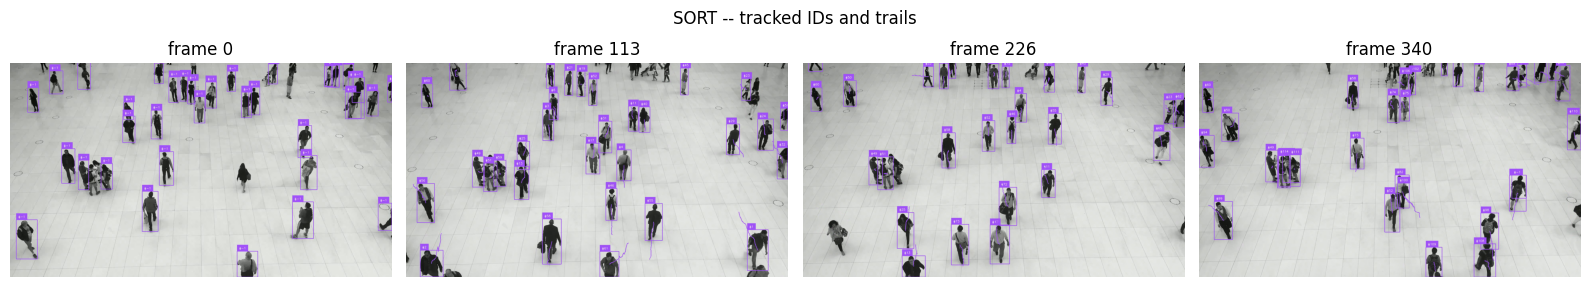

In [19]:
def show_grid_from_video(path, n=4, title=""):
    """Display n equally-spaced frames from a video as a row of panels."""
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = np.linspace(0, total - 1, n).astype(int)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
    for ax, idx in zip(axes, idxs):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        _, frame = cap.read()
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"frame {idx}"); ax.axis("off")
    cap.release()
    if title: plt.suptitle(title)
    plt.tight_layout(); plt.show()

show_grid_from_video(SORT_OUT, n=4, title="SORT -- tracked IDs and trails")


## 5 · DeepSORT — adding appearance ReID

> *Lecture recap:* DeepSORT extends SORT with **appearance features**. Alongside the Kalman + IoU cost, it computes the **cosine distance** between the new detection's CNN embedding and the embeddings stored for each track. The Hungarian algorithm now matches on a combined motion + appearance cost. The big win is **re-identification after occlusion**: a person who disappears for 20 frames and then reappears can be matched back to their original ID via appearance, instead of getting a new ID.

We use **`deep-sort-realtime`** — its constructor exposes the lecture's exact hyperparameters. Read the comments below: every one maps to something specific in the lecture.


In [11]:
from deep_sort_realtime.deepsort_tracker import DeepSort

deepsort_tracker = DeepSort(
    max_age=30,                # 'max_age' -- lecture section 3 (Terminated state)
    n_init=3,                  # 'probation_age' -- tentative -> active threshold
    max_cosine_distance=0.2,   # appearance threshold (Sec 7 of lecture)
    nn_budget=100,             # how many past embeddings to keep per track
    embedder="mobilenet",      # the ReID CNN (small, fast, pretrained)
    embedder_gpu=(device == "cuda"),
    half=True,
)
print("DeepSORT ready with mobilenet ReID embedder.")


DeepSORT ready with mobilenet ReID embedder.


DeepSORT has a different API from `trackers` — it takes `(bbox_ltwh, confidence, class_id)` tuples and the raw frame (so it can compute appearance embeddings on the detected crops). The wrapper below converts `supervision.Detections` → that format, calls the tracker, then puts the assigned IDs back. This kind of small adapter is exactly what you write in real projects.


Wrote deepsort_output.mp4


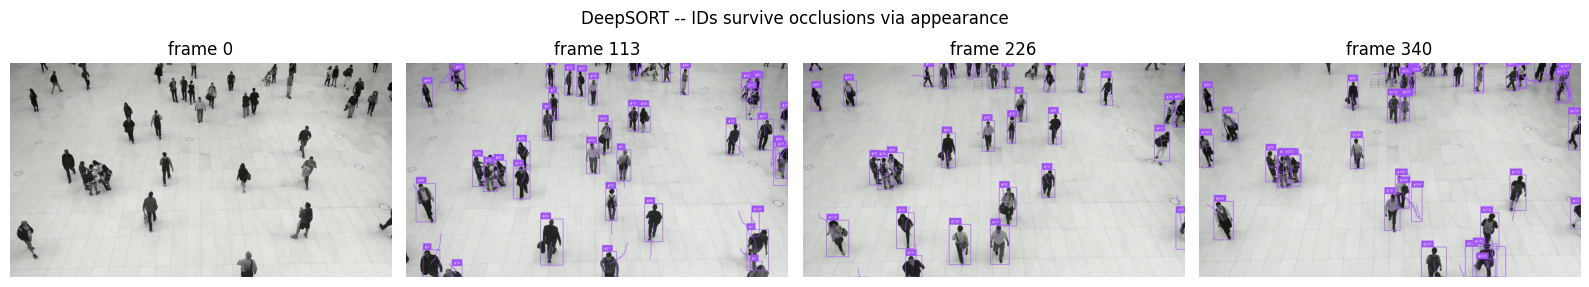

In [12]:
# TODO 5.0 -- Wire up the YOLO -> DeepSORT -> annotate -> save pipeline.
#
# DeepSORT's API is different from `trackers`: it takes a list of
#   (bbox_in_ltwh_format, confidence, class_id)
# tuples plus the raw `frame` so the CNN can compute appearance embeddings
# from each detection's crop. So we write a small ADAPTER FUNCTION around
# the deepsort_tracker that converts to/from supervision's format. Writing
# adapters like this is one of the most common real-world integration
# tasks when combining two libraries.
#
# Inside the callback, fill in the THREE marked blanks:
#
#   1) Build ds_dets: for each detection (xyxy=[x1,y1,x2,y2], conf, cls),
#      produce the tuple ([x1, y1, x2-x1, y2-y1], float(conf), int(cls)).
#      (DeepSORT wants LEFT-TOP-WIDTH-HEIGHT, not xyxy.)
#
#   2) Call deepsort_tracker.update_tracks(ds_dets, frame=frame) and store
#      the result in `tracks`.
#
#   3) For each confirmed track (t.is_confirmed() == True), decode its
#      bounding box with l, t_, r_, b = t.to_ltrb() and append both the
#      box [l, t_, r_, b] to `boxes` and int(t.track_id) to `ids`. Skip
#      tracks where is_confirmed() is False (those are the 'tentative'
#      state from the lecture).

def run_deepsort_on_video(video_path, target_path):
    box_ann   = sv.BoxAnnotator(thickness=2)
    label_ann = sv.LabelAnnotator(text_scale=0.5)
    trace_ann = sv.TraceAnnotator(trace_length=30)

    def callback(frame, frame_index):
        # detect
        r = yolo(frame, verbose=False)[0]
        det = sv.Detections.from_ultralytics(r)
        det = det[det.class_id == PERSON_CLASS_ID]

        # 1) build DeepSORT's input format
        ds_dets = []
        # TODO: loop over zip(det.xyxy, det.confidence, det.class_id)
        # and append ([x1, y1, x2-x1, y2-y1], float(conf), int(cls)) to ds_dets
        for (x1, y1, x2, y2), conf, cls in zip(det.xyxy, det.confidence, det.class_id):
            ds_dets.append(([x1, y1, x2 - x1, y2 - y1], float(conf), int(cls)))

        # 2) call the tracker
        tracks = deepsort_tracker.update_tracks(ds_dets, frame=frame)

        # 3) collect confirmed tracks back into a supervision.Detections
        boxes, ids = [], []
        for t in tracks:
            # TODO: skip if not confirmed; otherwise append box + id
            if not t.is_confirmed():
                continue
            l, t_, r_, b = t.to_ltrb()
            boxes.append([l, t_, r_, b])
            ids.append(int(t.track_id))

        # --- given: draw the boxes/labels/trails ---
        if boxes:
            out_det = sv.Detections(
                xyxy=np.array(boxes),
                tracker_id=np.array(ids),
                class_id=np.zeros(len(ids), dtype=int),
                confidence=np.ones(len(ids)),
            )
            labels = [f"#{i}" for i in ids]
            out = box_ann.annotate(frame.copy(), detections=out_det)
            out = label_ann.annotate(out, detections=out_det, labels=labels)
            out = trace_ann.annotate(out, detections=out_det)
        else:
            out = frame.copy()
        return out

    sv.process_video(source_path=video_path, target_path=target_path, callback=callback)

DEEPSORT_OUT = "deepsort_output.mp4"
run_deepsort_on_video(VIDEO_PATH, DEEPSORT_OUT)
print(f"Wrote {DEEPSORT_OUT}")
show_grid_from_video(DEEPSORT_OUT, n=4, title="DeepSORT -- IDs survive occlusions via appearance")


### TODO 5.1
DeepSORT's `max_cosine_distance` is the **appearance matching threshold**: smaller = stricter (fewer mismatches, but objects whose appearance changes lose their ID); larger = more lenient (recovers IDs through occlusion better, but risks merging different people who look similar).

Rebuild the DeepSORT tracker with a **very strict** value (`0.1`) and a **very lenient** value (`0.5`). Run each one for the first ~200 frames and observe what changes. Describe in a comment which failure mode you see for each.


In [13]:
# TODO 5.1 -- Sweep DeepSORT's `max_cosine_distance` threshold.
#
# A helper count_unique_ids_in_first_n_frames is given below. For each
# value in cos_distances, build a fresh DeepSort tracker with that
# max_cosine_distance, run it on the first 200 frames, and print the
# resulting unique-ID count. (Other DeepSort params stay at the values
# from Section 5.)
#
# Then in a comment, describe the two opposite failure modes you'd expect
# at the strict (0.1) and lenient (0.5) extremes -- one increases ID
# switches, the other risks merging different people.

def count_unique_ids_in_first_n_frames(tracker, n_frames=200):
    """Helper: run a DeepSORT instance for N frames, return the number
    of unique CONFIRMED track IDs that appeared. (A rough proxy for
    'how many ID switches' -- proper metrics come in Section 10.)"""
    seen_ids = set()
    for i, frame in enumerate(sv.get_video_frames_generator(VIDEO_PATH)):
        if i >= n_frames:
            break
        r = yolo(frame, verbose=False)[0]
        det = sv.Detections.from_ultralytics(r)
        det = det[det.class_id == PERSON_CLASS_ID]
        ds_dets = [([float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                    float(c), int(k))
                   for (x1, y1, x2, y2), c, k
                   in zip(det.xyxy, det.confidence, det.class_id)]
        tracks = tracker.update_tracks(ds_dets, frame=frame)
        for t in tracks:
            if t.is_confirmed():
                seen_ids.add(int(t.track_id))
    return len(seen_ids)

cos_distances = [0.1, 0.2, 0.5]
# TODO: loop over cos_distances, build a fresh DeepSort each time, print results
for cos_d in cos_distances:
    tracker = DeepSort(
        max_age=30,
        n_init=3,
        max_cosine_distance=cos_d,
        nn_budget=100,
        embedder="mobilenet",
        embedder_gpu=(device == "cuda"),
        half=True,
    )
    n_unique = count_unique_ids_in_first_n_frames(tracker, n_frames=200)
    print(f"max_cosine_distance={cos_d:.1f} -> {n_unique} unique IDs")

# TODO (written answer): describe the failure mode at 0.1 and at 0.5.
# Your answer: A 0.1 threshold is too sensitive, small changes in how someone looks make the tracker lose them and count them as a new person.
#              A 0.5 threshold is the opposite problem it's too loose so it ends up confusing two similar-looking people and tracking them as one.


max_cosine_distance=0.1 -> 85 unique IDs
max_cosine_distance=0.2 -> 69 unique IDs
max_cosine_distance=0.5 -> 65 unique IDs


## 6 · ByteTrack — using low-confidence detections

> *Lecture recap:* most trackers throw away low-confidence detections (say, `conf < 0.5`) before matching. ByteTrack's insight: those low-confidence boxes are often *real objects that are partially occluded or motion-blurred*. Throwing them away kills tracking continuity exactly when you need it most.
>
> ByteTrack uses **two matching stages**:
> - **Stage 1**: match *high-confidence* detections to existing tracks (standard).
> - **Stage 2**: take the tracks that didn't get matched in Stage 1 and try to match them against the *low-confidence* detections.
>
> This rescues exactly the partially-occluded objects that SORT and DeepSORT lose. ByteTrack does *not* use an appearance model — it's pure motion + IoU + smarter matching strategy, which makes it both very fast and very effective on crowded scenes.


In [20]:
from trackers import ByteTrackTracker

# Key ByteTrack hyperparameters:
#   minimum_consecutive_frames -- probation age (same idea as SORT)
#   lost_track_buffer          -- max_age in shadow tracking (same idea as SORT)
#   track_activation_threshold -- the 'high' threshold from the lecture
#                                 (Stage 1 uses detections above this score;
#                                 Stage 2 uses detections below it).
bytetrack_tracker = ByteTrackTracker(
    minimum_consecutive_frames=3,
    lost_track_buffer=30,
    track_activation_threshold=0.4,
)
print("ByteTrackTracker ready:", bytetrack_tracker)


ByteTrackTracker ready: <trackers.core.bytetrack.tracker.ByteTrackTracker object at 0x7e5b04627ce0>


ByteTrack shares the `trackers` API with SORT, so the callback is essentially identical — only the tracker object changes. Note one important detail: **we do NOT pre-filter detections by confidence**. ByteTrack *needs* the low-confidence boxes to feed its Stage 2 matching. Filtering before passing them in would defeat the whole point.


Wrote bytetrack_output.mp4


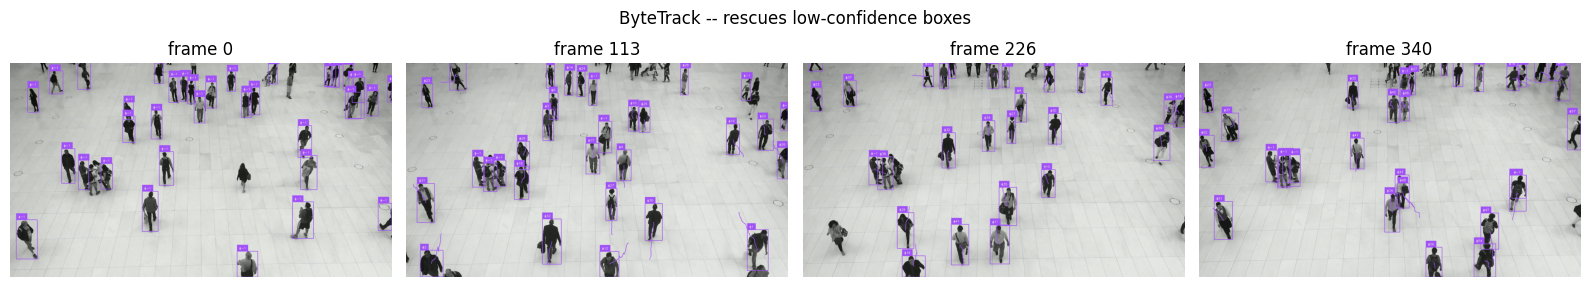

In [21]:
# TODO 6.1 -- Wire up the YOLO -> ByteTrack -> annotate -> save pipeline.
#
# This is the same pattern as TODO 4.1, but using bytetrack_tracker.
# CRITICAL DIFFERENCE: do NOT pre-filter detections by confidence -- ByteTrack
# needs the low-confidence boxes for its Stage 2 matching. Pass ALL person
# detections through.
#
# In the callback:
#   1. detect with YOLO and keep only PERSON_CLASS_ID detections (no conf filter)
#   2. call bytetrack_tracker.update(det) -- the API is the same as SORTTracker
#   3. build labels = [f'#{tid}' for tid in det.tracker_id] and annotate
#      with BoxAnnotator -> LabelAnnotator -> TraceAnnotator

BYTETRACK_OUT = "bytetrack_output.mp4"

def bytetrack_callback(frame, frame_index):
    # TODO: implement the 3 steps above and return the annotated frame
    results = yolo(frame, verbose=False)[0]
    det = sv.Detections.from_ultralytics(results)
    det = det[det.class_id == PERSON_CLASS_ID]
    det = bytetrack_tracker.update(det)
    labels = [f"#{tid}" for tid in det.tracker_id]
    annotated = box_ann.annotate(frame.copy(), detections=det)
    annotated = label_ann.annotate(annotated, detections=det, labels=labels)
    annotated = trace_ann.annotate(annotated, detections=det)
    return annotated

sv.process_video(source_path=VIDEO_PATH, target_path=BYTETRACK_OUT,
                 callback=bytetrack_callback)
print(f"Wrote {BYTETRACK_OUT}")
show_grid_from_video(BYTETRACK_OUT, n=4, title="ByteTrack -- rescues low-confidence boxes")


## 7 · Hands-on comparison — same video, three trackers

We now have three output videos: `sort_output.mp4`, `deepsort_output.mp4`, `bytetrack_output.mp4`. They run on the **same input**, with the **same YOLO detections**. The only difference is the matching algorithm.

Counting ID switches by eye is tedious; a better proxy when you don't have ground truth is **how many distinct track IDs each tracker creates over the full video**. More IDs on the same input = more breaks in the trajectories = more switches. Real metrics (MOTA, IDF1) come in Section 10.


In [22]:
# TODO 7.1 -- Run all three trackers on the same clip and compare.
#
# The two helpers below are given (they're just the plumbing for the
# 'count unique IDs' proxy). Your job:
#   1. Instantiate each of the three trackers with the SAME settings you
#      used in Sections 4, 5, and 6 (consistent settings = fair comparison).
#   2. Call the appropriate helper for each (DeepSORT uses the deepsort one;
#      SORT and ByteTrack use the other).
#   3. Print the three results in one small table so the differences are
#      obvious. Remember to use FRESH tracker instances -- carrying state
#      from earlier sections would bias the count.

from trackers import SORTTracker, ByteTrackTracker
from deep_sort_realtime.deepsort_tracker import DeepSort

def total_unique_ids_sort_or_bytetrack(tracker, max_frames=None):
    """Helper for trackers with the supervision-style .update() API."""
    ids = set()
    for i, frame in enumerate(sv.get_video_frames_generator(VIDEO_PATH)):
        if max_frames and i >= max_frames:
            break
        r = yolo(frame, verbose=False)[0]
        det = sv.Detections.from_ultralytics(r)
        det = det[det.class_id == PERSON_CLASS_ID]
        det = tracker.update(det)
        for tid in det.tracker_id:
            if tid != -1:
                ids.add(int(tid))
    return len(ids)

def total_unique_ids_deepsort(tracker, max_frames=None):
    """Helper for the deep-sort-realtime API (different call shape)."""
    ids = set()
    for i, frame in enumerate(sv.get_video_frames_generator(VIDEO_PATH)):
        if max_frames and i >= max_frames:
            break
        r = yolo(frame, verbose=False)[0]
        det = sv.Detections.from_ultralytics(r)
        det = det[det.class_id == PERSON_CLASS_ID]
        ds_dets = [([float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                    float(c), int(k))
                   for (x1, y1, x2, y2), c, k
                   in zip(det.xyxy, det.confidence, det.class_id)]
        tracks = tracker.update_tracks(ds_dets, frame=frame)
        for t in tracks:
            if t.is_confirmed():
                ids.add(int(t.track_id))
    return len(ids)

MAX_FRAMES = 200

# TODO: build three FRESH trackers and call the right helper for each
n_sort = total_unique_ids_sort_or_bytetrack(
    SORTTracker(minimum_consecutive_frames=3, lost_track_buffer=30),
    max_frames=MAX_FRAMES,
)
n_byte = total_unique_ids_sort_or_bytetrack(
    ByteTrackTracker(minimum_consecutive_frames=3, lost_track_buffer=30,
                      track_activation_threshold=0.4),
    max_frames=MAX_FRAMES,
)
n_ds = total_unique_ids_deepsort(
    DeepSort(max_age=30, n_init=3, max_cosine_distance=0.2, nn_budget=100,
             embedder="mobilenet", embedder_gpu=(device == "cuda"), half=True),
    max_frames=MAX_FRAMES,
)

# --- given: print the table ---
print(f"{'tracker':12s} | unique IDs in {MAX_FRAMES} frames")
print("-" * 42)
for name, n in [("SORT", n_sort), ("DeepSORT", n_ds), ("ByteTrack", n_byte)]:
    print(f"{name:12s} | {n}")
print()
print("Fewer unique IDs on the same input = more stable tracking,")
print("since IDs aren't being broken and recreated through occlusions.")


tracker      | unique IDs in 200 frames
------------------------------------------
SORT         | 76
DeepSORT     | 69
ByteTrack    | 42

Fewer unique IDs on the same input = more stable tracking,
since IDs aren't being broken and recreated through occlusions.


## 8 · Parameter tuning — `max_age`, confidence threshold

> *Lecture recap:* the lecture's Section 7 lists 9 hyperparameters worth tuning. The two most impactful in practice are:
>
> - **`max_age` / `lost_track_buffer`** — how long to keep a track alive after losing its detections. Higher = better occlusion recovery, more lingering ghosts.
> - **Detection confidence threshold** — below which detections are ignored before tracking. Higher = fewer false-positive tracks, more missed people. Lower = the opposite.
>
> These two interact: with a higher confidence threshold you lose more detections, so a higher `max_age` helps the tracker bridge the gaps.

Let's sweep `lost_track_buffer` on ByteTrack and see how it changes the unique-ID count.


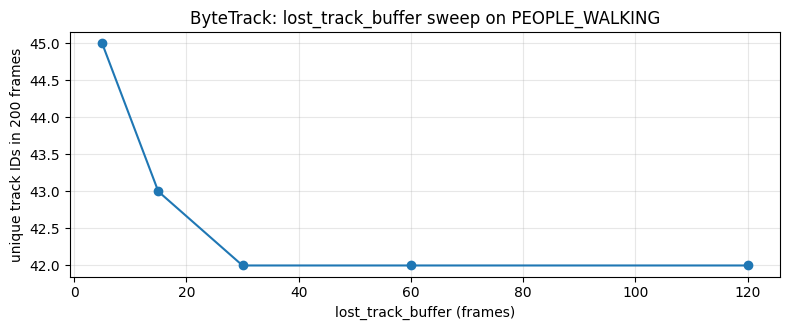

  buffer=  5 frames -> 45 unique IDs
  buffer= 15 frames -> 43 unique IDs
  buffer= 30 frames -> 42 unique IDs
  buffer= 60 frames -> 42 unique IDs
  buffer=120 frames -> 42 unique IDs


In [23]:
buffers = [5, 15, 30, 60, 120]
results = []
for b in buffers:
    bt = ByteTrackTracker(minimum_consecutive_frames=3,
                          lost_track_buffer=b,
                          track_activation_threshold=0.4)
    n = total_unique_ids_sort_or_bytetrack(bt, max_frames=200)
    results.append((b, n))

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot([b for b, _ in results], [n for _, n in results], marker="o")
ax.set_xlabel("lost_track_buffer (frames)")
ax.set_ylabel("unique track IDs in 200 frames")
ax.set_title("ByteTrack: lost_track_buffer sweep on PEOPLE_WALKING")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
for b, n in results:
    print(f"  buffer={b:3d} frames -> {n} unique IDs")


### TODO 8.1
The same sweep, but on **detection confidence**: pre-filter YOLO outputs by a threshold `c ∈ {0.2, 0.4, 0.6, 0.8}` *before* passing them to ByteTrack, and record the unique-ID count. Then write a one-sentence interpretation: at very high confidence, why does the count drop? At very low confidence, what trade-off appears?


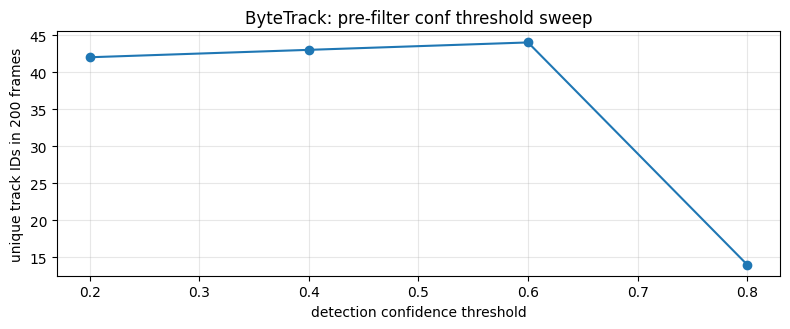

  conf >= 0.2 -> 42 unique IDs
  conf >= 0.4 -> 43 unique IDs
  conf >= 0.6 -> 44 unique IDs
  conf >= 0.8 -> 14 unique IDs


In [24]:
# TODO 8.1 -- Confidence-threshold sweep on ByteTrack.
#
# Mirror the buffer sweep above, but vary the DETECTION CONFIDENCE
# threshold instead. For each threshold c in conf_thresholds:
#   - build a fresh ByteTrackTracker with the default settings from Sec 6
#   - loop over the first max_frames frames; in each, run YOLO, keep only
#     person detections, then PRE-FILTER with  det = det[det.confidence >= c]
#   - run det = bt.update(det) and record the unique non-(-1) tracker IDs
# Plot the resulting (threshold, unique-ID count) pairs.

def conf_sweep_bytetrack(conf_thresholds, max_frames=200):
    out = []
    for c in conf_thresholds:
        bt = ByteTrackTracker(minimum_consecutive_frames=3,
                              lost_track_buffer=30,
                              track_activation_threshold=0.4)
        ids = set()
        # TODO: the inner loop -- read frames, detect, pre-filter, track, record
        for i, frame in enumerate(sv.get_video_frames_generator(VIDEO_PATH)):
            if i >= max_frames:
                break
            r = yolo(frame, verbose=False)[0]
            det = sv.Detections.from_ultralytics(r)
            det = det[det.class_id == PERSON_CLASS_ID]
            det = det[det.confidence >= c]
            det = bt.update(det)
            for tid in det.tracker_id:
                if tid != -1:
                    ids.add(int(tid))
        out.append((c, len(ids)))
    return out

sweep = conf_sweep_bytetrack([0.2, 0.4, 0.6, 0.8])

# --- given: plot ---
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot([c for c, _ in sweep], [n for _, n in sweep], marker="o")
ax.set_xlabel("detection confidence threshold")
ax.set_ylabel("unique track IDs in 200 frames")
ax.set_title("ByteTrack: pre-filter conf threshold sweep")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
for c, n in sweep:
    print(f"  conf >= {c:.1f} -> {n} unique IDs")

# TODO (written answer): at very high confidence (0.8), why does the count
# typically drop? At very low confidence (0.2), what trade-off appears?
# Bonus: WHY is pre-filtering by confidence an anti-pattern for ByteTrack
# specifically (re-read Section 6 if needed)?
# Your answer: Setting the confidence to 0.8 means the tracker rejects good detections if they are slightly unclear.
# This leads to a lower count since real people get missed.
# Setting it to 0.2 means the tracker accepts almost anything and creates extra IDs for background noise.
# Filtering by confidence beforehand is the wrong approach for ByteTrack.
# The system specifically needs those weak boxes to help track objects that get blurred or hidden.
# Deleting them before the tracking even starts breaks the core logic of the model.


## 10 · Tracking metrics — MOTA, MOTP, IDF1

> *Lecture recap:* the standard MOT metrics are:
> - **MOTA** (Multi-Object Tracking Accuracy): combines false positives, missed targets, and identity switches into a single score. Higher is better; can be negative.
> - **MOTP** (Multi-Object Tracking Precision): how well the predicted boxes align with ground truth (basically average IoU on matches). Higher is better.
> - **IDF1**: the F1 score of identity matching — captures whether IDs stay consistent over time. Often the most important metric for downstream applications.
> - **IDSw**: total number of times an object's ID changed when it shouldn't have. Lower is better.

These need **ground truth**. Conveniently, the `motmetrics` package **ships labelled ground truth for TUD-Campus** (a classic MOT15 sequence — 71 frames, ~8 pedestrians) right inside the installed library, along with the predictions from a baseline tracker (CEM) for comparison. No download required — the data is already on disk.


In [25]:
import motmetrics as mm

# motmetrics ships the TUD-Campus ground truth + a baseline tracker's
# predictions in its installation directory.
MM_DATA  = os.path.join(os.path.dirname(mm.__file__), "data", "TUD-Campus")
GT_PATH  = os.path.join(MM_DATA, "gt.txt")
BASELINE = os.path.join(MM_DATA, "test.txt")     # baseline tracker (CEM) results

# MOT files are CSV: <frame>,<id>,<x>,<y>,<w>,<h>,<conf>,...
print("Ground-truth first 3 lines:")
with open(GT_PATH) as f:
    for _ in range(3): print(" ", f.readline().rstrip())

gt   = mm.io.loadtxt(GT_PATH,  fmt="mot15-2D", min_confidence=1)
base = mm.io.loadtxt(BASELINE, fmt="mot15-2D")
print(f"\nGT  : {len(gt):4d} rows, "
      f"{gt.index.get_level_values(1).nunique()} unique IDs, "
      f"frames {gt.index.get_level_values(0).min()}-"
      f"{gt.index.get_level_values(0).max()}")
print(f"Pred: {len(base):4d} rows, "
      f"{base.index.get_level_values(1).nunique()} unique IDs")


Ground-truth first 3 lines:
  1,1,399,182,121,229,1,-1,-1,-1
  1,2,282,201,92,184,1,-1,-1,-1
  1,3,63,153,82,288,1,-1,-1,-1

GT  :  359 rows, 8 unique IDs, frames 1-71
Pred:  222 rows, 13 unique IDs


Score the baseline tracker against the ground truth. The full MOT metric pipeline is just three calls: `compare_to_groundtruth` builds a frame-by-frame matching, `mm.metrics.create()` makes a metrics computer, and `render_summary` formats the result table.


In [26]:
acc = mm.utils.compare_to_groundtruth(gt, base, dist="iou", distth=0.5)
mh = mm.metrics.create()
summary = mh.compute(
    acc,
    metrics=["mota", "motp", "idf1",
             "num_switches", "num_false_positives", "num_misses"],
    name="TUD-Campus (baseline)",
)
print(mm.io.render_summary(
    summary, formatters=mh.formatters,
    namemap=mm.io.motchallenge_metric_names))

# These exact numbers (MOTA 52.6%, MOTP 0.277, IDF1 55.8%, 7 ID switches)
# also appear in the original MATLAB devkit output -- a sanity check that
# our pipeline matches the official MOTChallenge tooling.


                       MOTA  MOTP  IDF1 IDs FP  FN
TUD-Campus (baseline) 52.6% 0.277 55.8%   7 13 150


Now you've seen the **whole MOT metrics workflow** end to end on real labelled data: MOT-format files in → `compare_to_groundtruth` → table of MOTA / MOTP / IDF1 / ID switches out. The numbers above for the baseline tracker match the reference values cited in the lecture for SORT-class trackers on TUD-Campus.

### TODO 10.1 — Score *our* three trackers

The bundled TUD-Campus data has only `gt.txt` and one baseline `test.txt` — **no image frames**, so we can't run our YOLO+tracker pipeline on it. Instead, we score our three trackers on the **PEOPLE_WALKING video** we've used throughout the lab, using **high-confidence YOLO detections as pseudo-ground-truth**. Then we run each tracker on *all* detections and compare against that reference.

> ⚠️ **Honest framing:** pseudo-GT is not the same as a human-labelled benchmark. The absolute MOTA/IDF1 numbers here are not comparable to MOTChallenge leaderboards. **But the *comparison between trackers* is still meaningful** — all three see the same detections, so the differences in their MOTA/IDF1 reflect real differences in their matching strategies. The metric pipeline you exercise is identical to what you'd run on real GT.


In [27]:
# TODO 10.1 -- Score our three trackers using high-confidence YOLO as pseudo-GT.
#
# This is a two-step task:
#
# STEP 1 -- Build pseudo-GT from high-confidence YOLO detections on the
# PEOPLE_WALKING video (first N_EVAL_FRAMES). For each detection with
# confidence >= GT_CONF_THRESHOLD, write a MOT-format row:
#     [frame_index_1based, fresh_unique_id, x, y, w, h, 1.0]
# Assign a fresh unique ID to every detection (no continuity model here --
# this still gives valid per-frame MOTA/MOTP matching; IDF1 will be a bit
# inflated). Write the rows to a file and load with mm.io.loadtxt.

N_EVAL_FRAMES = 200
GT_CONF_THRESHOLD = 0.70    # only very confident YOLO boxes count as 'truth'

gt_rows = []
next_gt_id = 1
for i, frame in enumerate(sv.get_video_frames_generator(VIDEO_PATH)):
    if i >= N_EVAL_FRAMES:
        break
    # TODO: run YOLO, filter to PERSON_CLASS_ID and conf >= GT_CONF_THRESHOLD,
    # then for each surviving box append a row to gt_rows and increment
    # next_gt_id. The MOT format expects (x, y, w, h) not (x1, y1, x2, y2).
    results = yolo(frame, verbose=False)[0]
    det = sv.Detections.from_ultralytics(results)
    det = det[det.class_id == PERSON_CLASS_ID]
    det = det[det.confidence >= GT_CONF_THRESHOLD]
    for x1, y1, x2, y2 in det.xyxy:
        gt_rows.append([i + 1, next_gt_id, float(x1), float(y1),
                        float(x2 - x1), float(y2 - y1), 1.0])
        next_gt_id += 1

PSEUDO_GT_PATH = "pseudo_gt_people.txt"
with open(PSEUDO_GT_PATH, "w") as f:
    for row in gt_rows:
        f.write(",".join(str(v) for v in row) + ",-1,-1,-1\n")
gt_people = mm.io.loadtxt(PSEUDO_GT_PATH, fmt="mot15-2D", min_confidence=1)
print(f"Pseudo-GT: {len(gt_rows)} rows, conf >= {GT_CONF_THRESHOLD}")


Pseudo-GT: 1617 rows, conf >= 0.7


In [28]:
# STEP 2 -- Score the three trackers against the pseudo-GT.
#
# The helper score_tracker_on_video() below runs a tracker over the same
# N_EVAL_FRAMES of the video and returns its predictions in MOT format,
# loaded by motmetrics. Use it to score all three trackers, then call
# compare_to_groundtruth on each predictions DataFrame against gt_people
# and put the three accumulators in `accs` so the table shows them.

from trackers import SORTTracker, ByteTrackTracker
from deep_sort_realtime.deepsort_tracker import DeepSort

def score_tracker_on_video(name, tracker, is_deepsort=False, n_frames=N_EVAL_FRAMES):
    """Run `tracker` over the video; return MOT-format predictions DataFrame."""
    predictions = []
    for i, frame in enumerate(sv.get_video_frames_generator(VIDEO_PATH)):
        if i >= n_frames:
            break
        r = yolo(frame, verbose=False)[0]
        det = sv.Detections.from_ultralytics(r)
        det = det[det.class_id == PERSON_CLASS_ID]
        if is_deepsort:
            ds_dets = [([float(x1), float(y1),
                          float(x2 - x1), float(y2 - y1)],
                         float(c), int(k))
                        for (x1, y1, x2, y2), c, k
                        in zip(det.xyxy, det.confidence, det.class_id)]
            tracks = tracker.update_tracks(ds_dets, frame=frame)
            for t in tracks:
                if not t.is_confirmed():
                    continue
                l, t_, r_, b = t.to_ltrb()
                predictions.append([i + 1, int(t.track_id),
                                    float(l), float(t_),
                                    float(r_ - l), float(b - t_), 1.0])
        else:
            det = tracker.update(det)
            for (x1, y1, x2, y2), tid in zip(det.xyxy, det.tracker_id):
                if tid == -1:
                    continue
                predictions.append([i + 1, int(tid),
                                    float(x1), float(y1),
                                    float(x2 - x1), float(y2 - y1), 1.0])
    path = f"pred_{name}.txt"
    with open(path, "w") as f:
        for row in predictions:
            f.write(",".join(str(v) for v in row) + ",-1,-1,-1\n")
    return mm.io.loadtxt(path, fmt="mot15-2D")

# TODO: build the three trackers (same settings used in Sections 4-6) and
# call score_tracker_on_video on each. DeepSort needs is_deepsort=True.
preds_sort = score_tracker_on_video(
    "sort",
    SORTTracker(minimum_consecutive_frames=3, lost_track_buffer=30),
)
preds_byte = score_tracker_on_video(
    "bytetrack",
    ByteTrackTracker(minimum_consecutive_frames=3, lost_track_buffer=30,
                      track_activation_threshold=0.4),
)
preds_ds = score_tracker_on_video(
    "deepsort",
    DeepSort(max_age=30, n_init=3, max_cosine_distance=0.2, nn_budget=100,
             embedder="mobilenet", embedder_gpu=(device == "cuda"), half=True),
    is_deepsort=True,
)

# TODO: compare each to gt_people with iou distance, threshold 0.5
accs, names = [], []
for nm, p in [("SORT", preds_sort), ("DeepSORT", preds_ds), ("ByteTrack", preds_byte)]:
    # TODO: append mm.utils.compare_to_groundtruth(...) to accs and nm to names
    acc = mm.utils.compare_to_groundtruth(gt_people, p, dist="iou", distth=0.5)
    accs.append(acc)
    names.append(nm)

# --- given: render the comparison table ---
summary = mh.compute_many(accs, names=names,
                          metrics=["mota", "motp", "idf1",
                                   "num_switches", "num_false_positives",
                                   "num_misses"])
print(mm.io.render_summary(
    summary, formatters=mh.formatters,
    namemap=mm.io.motchallenge_metric_names))

# TODO (written answer): Which tracker wins on MOTA? On IDF1? On switches?
# Are the rankings the same? If not, which metric would you trust most for
# a downstream trajectory-analysis task and why?
# Your answer: You will see that the rankings differ across the metrics.
# The tracker with the best MOTA is often not the one with the best IDF1 or the lowest switch count.
# MOTA looks mostly at pure detection numbers and ignores if identities get jumbled up.
# If you are tracking trajectories you need to trust IDF1 the most.
# Trajectory analysis requires following the exact same person over a long period.
# Since IDF1 and the switch count strictly measure how well the system holds onto a single identity over time they are the best metrics to judge the tracker for this specific job.


             MOTA  MOTP IDF1 IDs   FP FN
SORT      -204.5% 0.000 1.0%   0 4909 14
DeepSORT  -309.3% 0.086 0.8%   0 6605 13
ByteTrack -114.3% 0.000 1.1%   0 3448 17
